In [41]:
import sys; sys.path.insert(0, '..')

# Ensure local utils/ is found before labs/02/utils/
import importlib
if 'utils' in sys.modules:
    del sys.modules['utils']
sys.path.insert(0, '.')

import ugradiolab.plotting as plotting  # applies rcParams
from ugradiolab.plotting import SS_FINE
from plotters import plot_spectra_grid, plot_heatmap, plot_survey_mollweide
from utils import (flag_rfi_channels, flag_outlier_dumps, vlsr_correction,
                   compute_R_for_dumps, compute_cell_W, build_heatmap)

import re
from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

%matplotlib inline

## 1. Load all scan dumps

In [42]:
STREAMING_DIR = Path('../../../data/lab04/streaming')

scan_dirs = []
for session_dir in sorted(STREAMING_DIR.glob('session_*')):
    found = sorted(session_dir.glob('obs_*'))
    print(f'{session_dir.name}: {len(found)} obs cells')
    scan_dirs.extend(found)

print(f'Total: {len(scan_dirs)} obs cells')

# Collect all dumps
records = []
for d in scan_dirs:
    session_label = d.parent.name
    for p in sorted(d.glob('*.npz')):
        with np.load(p, allow_pickle=True) as f:
            records.append({
                'path': p,
                'session': session_label,
                'target': str(f['target_name']),
                'corr00': f['corr00'].astype(float),
                'corr11': f['corr11'].astype(float),
                'lo_mhz': float(f['lo_freq_mhz']),
                'noise_on': bool(f['noise_on']),
                'time': float(f['time']),
                'alt': float(f['alt_deg']),
                'az': float(f['az_deg']),
                'ra': float(f['ra_deg']),
                'dec': float(f['dec_deg']),
            })

N = len(records)
print(f'{N} total dumps loaded')

# Extract galactic coordinates directly from target_name (obs_{l}_{b} format)
for r in records:
    m = re.match(r'(?:obs|cal)_(-?\d+)_(-?\d+)', r['target'])
    if m:
        r['gl'] = int(m.group(1))
        r['gb'] = int(m.group(2))
    else:
        r['gl'] = None
        r['gb'] = None

sessions = sorted(set(r['session'] for r in records))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

for s in sessions:
    n_s = sum(1 for r in records if r['session'] == s)
    if n_s > 0:
        print(f'  {s}: {n_s} dumps')
gl_vals = sorted(set(r['gl'] for r in records if r['gl'] is not None))
gb_vals = sorted(set(r['gb'] for r in records if r['gb'] is not None))
print(f'Grid: {len(gb_vals)} b-rows x {len(gl_vals)} l-cols')
print(f'LO: {lo_unique}')
print(f'Cal dumps: {n_cal}, Science dumps: {n_sci}')


session_001: 153 obs cells
session_002: 14 obs cells
session_003: 95 obs cells
session_004: 67 obs cells
session_005: 19 obs cells
session_006: 97 obs cells
session_007: 80 obs cells
session_008: 75 obs cells
session_009: 153 obs cells
session_010: 40 obs cells
session_011: 32 obs cells
session_012: 241 obs cells
session_013: 17 obs cells
session_014: 77 obs cells
session_015: 7 obs cells
session_016: 26 obs cells
session_017: 4 obs cells
session_018: 101 obs cells
session_019: 4 obs cells
session_020: 1 obs cells
session_021: 17 obs cells
session_022: 4 obs cells
session_023: 15 obs cells
session_024: 3 obs cells
session_025: 3 obs cells
session_026: 51 obs cells
session_027: 169 obs cells
session_029: 2 obs cells
session_030: 7 obs cells
session_031: 15 obs cells
Total: 1589 obs cells
12911 total dumps loaded
  session_001: 1221 dumps
  session_002: 428 dumps
  session_003: 754 dumps
  session_004: 533 dumps
  session_005: 145 dumps
  session_006: 771 dumps
  session_007: 637 dumps
 

## 2. fftshift + mask DC + RFI flagging

In [43]:
DC_BIN = NFFT // 2
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0/SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])

    # Mask DC bin (LO spike at baseband 0 = channel 512 after fftshift)
    r['corr00'][DC_BIN] = np.nan
    r['corr11'][DC_BIN] = np.nan

    # For LO=1420: mask 2 bins below DC to suppress leakage near HI line.
    if r['lo_mhz'] == 1420.0:
        for ch in [DC_BIN - 2, DC_BIN - 1]:
            r['corr00'][ch] = np.nan
            r['corr11'][ch] = np.nan

    r['stokes_I'] = r['corr00'] + r['corr11']

# RFI flagging: rolling median + MAD, flags both positive and
# negative outliers (spikes and dropouts).
RFI_WINDOW = 15
RFI_SIGMA = 5.0
n_flagged = sum(flag_rfi_channels(r['stokes_I'], RFI_WINDOW, RFI_SIGMA)
                for r in records)

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz')
print(f'dnu = {df_khz:.2f} kHz')
print(f'Masked DC bin: channel {DC_BIN}')
print(f'Masked DC leakage: channels {DC_BIN-2}, {DC_BIN-1} (LO=1420 only)')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')

Baseband: [-1.280, 1.278] MHz
dnu = 2.50 kHz
Masked DC bin: channel 512
Masked DC leakage: channels 510, 511 (LO=1420 only)
RFI flagged: 1100145 samples across 12911 dumps


In [44]:
import warnings

SHAPE_DEV_THRESH = 0.10
SHAPE_FRAC_THRESH = 0.20

outlier_records = flag_outlier_dumps(records, SHAPE_DEV_THRESH, SHAPE_FRAC_THRESH)
n_outlier_removed = len(outlier_records)
N = len(records)

print(f'Outlier dump filter (spectral shape): removed {n_outlier_removed} dumps')
print(f'  (flag if >{SHAPE_FRAC_THRESH:.0%} of channels deviate '
      f'>{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {N} dumps')

Outlier dump filter (spectral shape): removed 25 dumps
  (flag if >20% of channels deviate >10% from group median)
Remaining: 12886 dumps


## 3. Frequency-switched profiles per cell

For each cell, pair dumps at the two LO frequencies and compute
`R = (I1 - I2) / I2`.

**LSR correction**: Each dump's topocentric velocity is shifted to the
kinematic LSR frame (solar motion 20 km/s toward 18h +30deg B1900).
Per-DR results stay in the topocentric frame (intra-session shift < 0.01 km/s).
Combined results interpolate each DR onto a common LSR velocity grid before
averaging, correcting for Earth's orbital motion between sessions.

In [45]:
import astropy.coordinates as ac
import astropy.units as u_ast
from astropy.time import Time as AstroTime
from collections import defaultdict

EDGE_TRIM_MHZ = 0.256
MOLL_CENTER_L = 120.0

lo1, lo2 = lo_unique[0], lo_unique[1]
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)  # topocentric
dv_kms = np.abs(np.median(np.diff(v_overlap)))

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')

# --- Assign galactic coords ---
for r in records:
    if r.get('gl') is None:
        r['gl'], r['gb'] = None, None
        continue
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    r['gl'] = round(c.galactic.l.deg)
    r['gb'] = round(c.galactic.b.deg)

# --- LSR velocity correction ---
# v_LSR = v_topo + v_corr, where v_corr = heliocentric + solar motion to LSRK.
# Compute one correction per (DR, cell) group -- all dumps in a group are
# taken within minutes, so share the same correction to < 0.01 km/s.
print('Computing LSR corrections...')
cell_dr_groups = defaultdict(list)
for r in records:
    if r.get('gl') is None or r['noise_on']:
        r['v_corr_lsr'] = 0.0
        continue
    cell_dr_groups[(r['session'], r['gl'], r['gb'])].append(r)

for key, group in cell_dr_groups.items():
    r0 = group[0]
    mean_t = np.mean([r['time'] for r in group])
    v_corr = vlsr_correction(r0['ra'], r0['dec'], mean_t)
    for r in group:
        r['v_corr_lsr'] = v_corr

sci_vcorr = [r['v_corr_lsr'] for r in records
             if r.get('gl') is not None and not r['noise_on']]
mean_vcorr = np.mean(sci_vcorr)
print(f'  Range: {min(sci_vcorr):.2f} to {max(sci_vcorr):.2f} km/s '
      f'(mean {mean_vcorr:.2f})')

# Common LSR velocity grid for combined results
v_lsr_overlap = v_overlap + mean_vcorr
print(f'Velocity (LSR):  [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')

# Per-DR LSR corrections
for dr in sessions:
    dr_vc = [r['v_corr_lsr'] for r in records
             if r['session'] == dr and r.get('gl') is not None and not r['noise_on']]
    if dr_vc:
        print(f'  {dr}: v_corr = {np.mean(dr_vc):+.2f} km/s '
              f'(shift vs ref: {np.mean(dr_vc) - mean_vcorr:+.2f})')

# --- All unique (l, b) pointings ---
all_pointings = sorted(set((r['gl'], r['gb']) for r in records
                           if r['gl'] is not None))

# --- Build results ---
cell_results = {}           # per-DR, topocentric (for per-DR plots)
cell_results_combined = {}  # combined, LSR-corrected

for gl, gb in all_pointings:
    sci_dumps = [r for r in records
                 if r['gl'] == gl and r['gb'] == gb and not r['noise_on']]

    # Combined with LSR correction
    result = compute_R_for_dumps(sci_dumps, lo1, lo2, overlap_mask, v_overlap,
                                 lsr_correct=True, v_lsr_grid=v_lsr_overlap)
    if result is not None:
        cell_results_combined[(gl, gb)] = result

    # Per DR (topocentric -- intra-session shift is negligible)
    for dr in sessions:
        dr_dumps = [r for r in sci_dumps if r['session'] == dr]
        result = compute_R_for_dumps(dr_dumps, lo1, lo2, overlap_mask, v_overlap)
        if result is not None:
            cell_results[(dr, gl, gb)] = result

for dr in sessions:
    n = sum(1 for k in cell_results if k[0] == dr)
    print(f'  {dr}: {n} cells')
print(f'  Combined (LSR): {len(cell_results_combined)} cells')

LO pair: (1420.0, 1421.0) MHz
Overlap: [1419.98, 1421.02] MHz
Velocity (topo): [-130, 90] km/s
dv = 0.528 km/s per channel
Computing LSR corrections...
  Range: -43.89 to 43.33 km/s (mean -14.24)
Velocity (LSR):  [-144, 76] km/s
  session_001: v_corr = +24.45 km/s (shift vs ref: +38.69)
  session_002: v_corr = -33.58 km/s (shift vs ref: -19.34)
  session_003: v_corr = +11.25 km/s (shift vs ref: +25.49)
  session_004: v_corr = -32.89 km/s (shift vs ref: -18.65)
  session_005: v_corr = -39.99 km/s (shift vs ref: -25.76)
  session_006: v_corr = -36.02 km/s (shift vs ref: -21.78)
  session_007: v_corr = +28.55 km/s (shift vs ref: +42.79)
  session_008: v_corr = -18.46 km/s (shift vs ref: -4.22)
  session_009: v_corr = -36.79 km/s (shift vs ref: -22.56)
  session_010: v_corr = -41.64 km/s (shift vs ref: -27.40)
  session_011: v_corr = -3.51 km/s (shift vs ref: +10.73)
  session_012: v_corr = -37.16 km/s (shift vs ref: -22.92)
  session_013: v_corr = +40.71 km/s (shift vs ref: +54.95)
  sess

/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:70: RuntimeWarning: Mean of empty slice
  R_sess = np.nanmean(R_pairs, axis=0)
/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:95: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_all, axis=0)
/home/ikaros/projects/ay-121/labs/04/notebooks/utils/freqswitch.py:107: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_cat, axis=0)


  session_001: 153 cells
  session_002: 14 cells
  session_003: 95 cells
  session_004: 67 cells
  session_005: 19 cells
  session_006: 97 cells
  session_007: 80 cells
  session_008: 75 cells
  session_009: 153 cells
  session_010: 40 cells
  session_011: 32 cells
  session_012: 241 cells
  session_013: 17 cells
  session_014: 76 cells
  session_015: 7 cells
  session_016: 26 cells
  session_017: 4 cells
  session_018: 100 cells
  session_019: 4 cells
  session_020: 1 cells
  session_021: 16 cells
  session_022: 4 cells
  session_023: 14 cells
  session_024: 3 cells
  session_025: 3 cells
  session_026: 51 cells
  session_027: 169 cells
  session_029: 2 cells
  session_030: 7 cells
  session_031: 15 cells
  Combined (LSR): 1536 cells


## 4. Neighbor-based QA

Flag cells whose integrated intensity or peak velocity deviates
from the beam-weighted local plane fit of their neighbors.

Neighbor diagnostics: 1536 cells
  Using the overlap window with 418 channels and dv=0.528 km/s
  Neighborhood: cells within 4.5 deg, min neighbors=5
  Beam weight: Gaussian overlap with HPBW=3.4 deg
  Thresholds: |dW/W_local| > 30% and |z_W| > 3.5; |dv_peak| > 15 km/s and |z_v| > 4.0
  Flags: W=16, peak_v=2, any=17
  Most deviant cells:
    l=208 b=  0 W=+34.711 (frac=+0.04, z=+0.36) v_peak=+38.5 km/s (dv=+22.4, z=+7.47) n=36
    l=147 b= -1 W=+15.243 (frac=-0.53, z=-11.72) v_peak=-48.5 km/s (dv=-17.9, z=-4.33) n=33
    l=266 b= 24 W=+16.895 (frac=+2.02, z=+25.44) v_peak=-3.2 km/s (dv=+1.0, z=+0.34) n=15
    l= 12 b= -4 W=+14.199 (frac=+1.40, z=+6.44) v_peak=+7.4 km/s (dv=+3.5, z=+1.15) n=5
    l= 12 b= -2 W=+16.292 (frac=-0.33, z=-5.59) v_peak=+5.8 km/s (dv=-3.1, z=-1.03) n=5
    l=250 b= 24 W=+0.190 (frac=-0.96, z=-4.69) v_peak=-5.8 km/s (dv=-0.4, z=-0.12) n=20
    l=242 b= 22 W=+0.756 (frac=-0.87, z=-5.67) v_peak=-2.6 km/s (dv=-1.4, z=-0.46) n=20
    l=159 b= 23 W=+8.472 (frac=+0.7

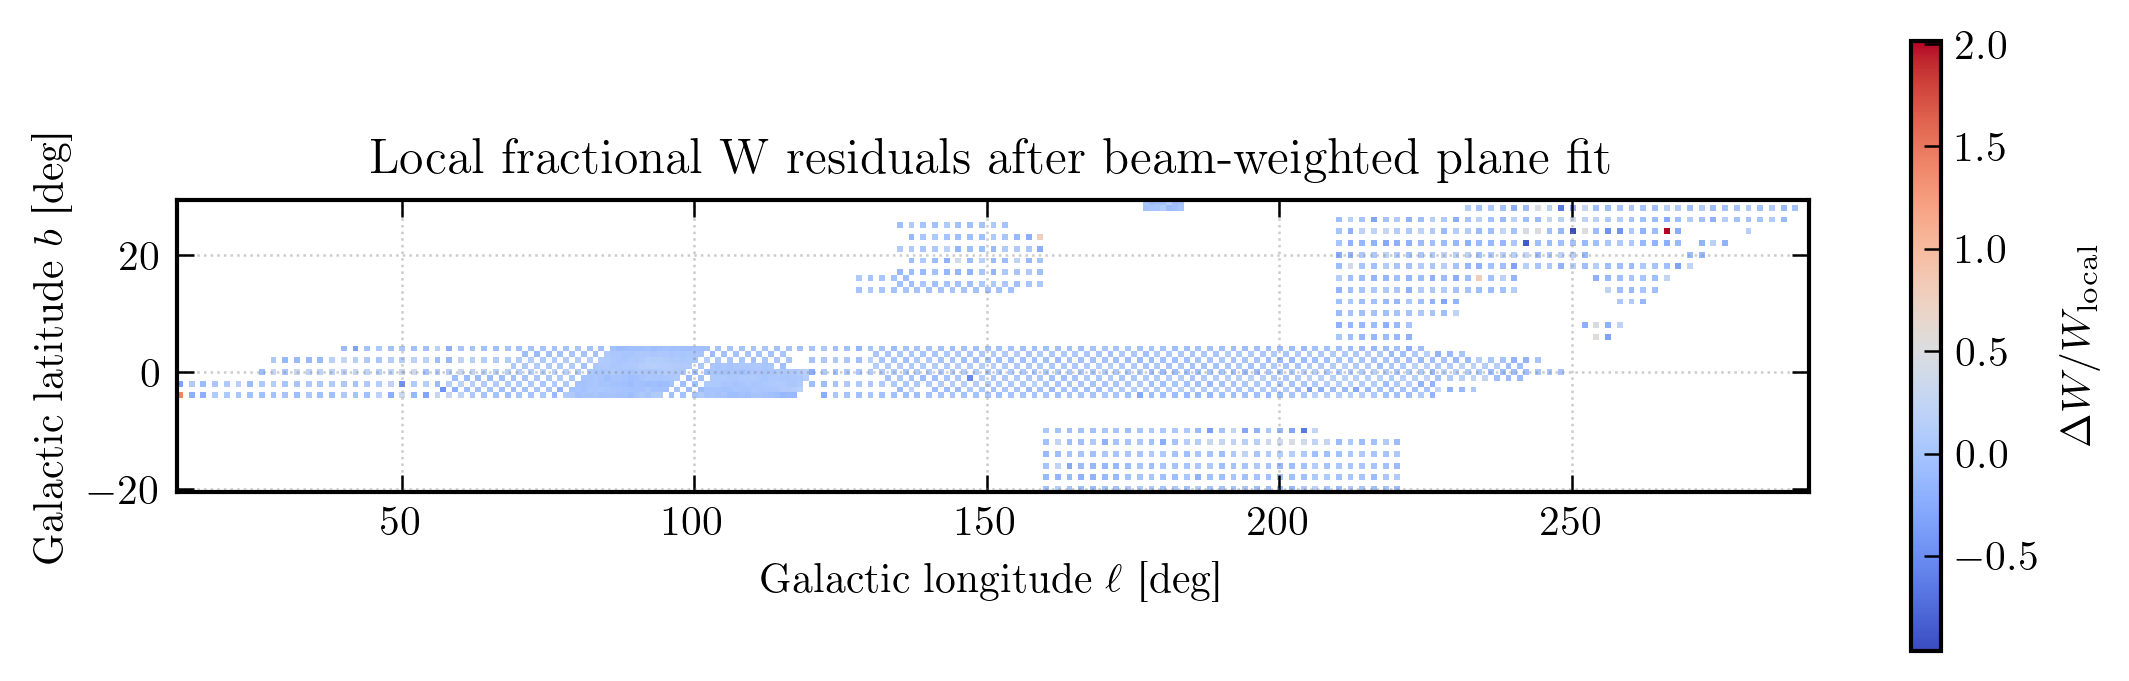

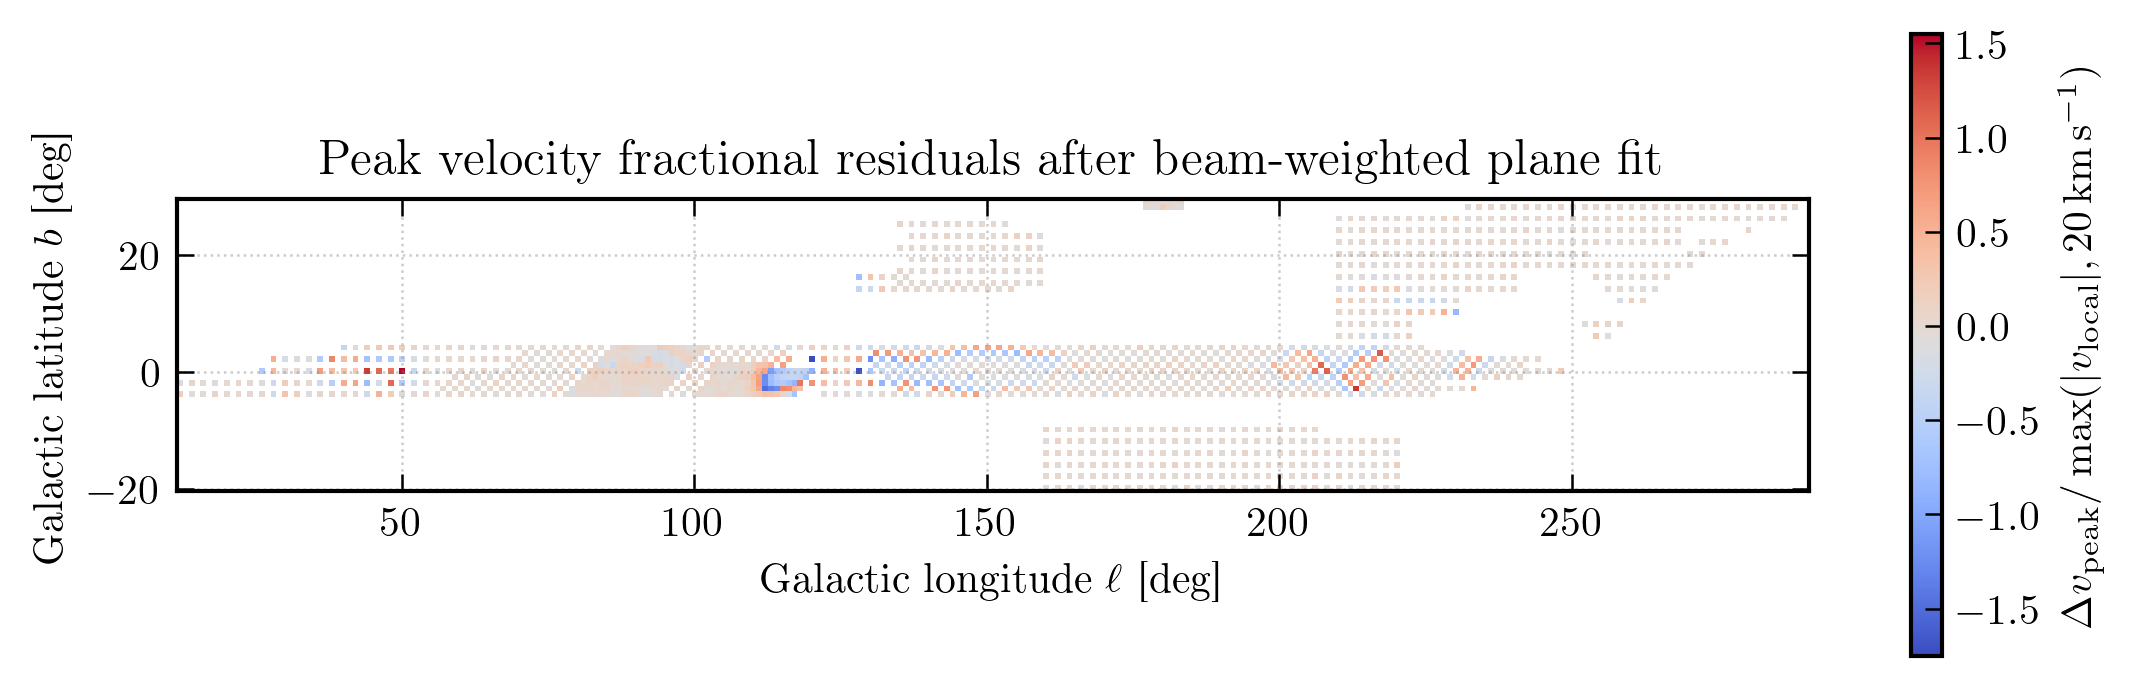

In [46]:
from scipy.signal import find_peaks

# Neighbor QA on the overlap-aligned survey grid.
# Use a beam-weighted local plane so smooth sky gradients are modeled out
# before flagging residual outliers.
HPBW_DEG = 3.4
NEIGHBOR_MAX_SEP_DEG = 4.5
MIN_NEIGHBORS = 5
W_Z_THRESH = 3.5
W_FRAC_THRESH = 0.30
W_SCALE_FLOOR = 5.0
PEAK_V_Z_THRESH = 4.0
PEAK_V_ABS_THRESH = 15.0
PEAK_V_MIN_SIGMA = 3.0
PEAK_V_SCALE_FLOOR = 20.0


def weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.nan
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights)
    cutoff = 0.5 * cdf[-1]
    return values[np.searchsorted(cdf, cutoff)]


def weighted_mad(values, weights, center=None):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.nan
    if center is None:
        center = weighted_median(values, weights)
    return weighted_median(np.abs(values - center), weights)


def beam_overlap_weight(sep_deg, hpbw_deg=HPBW_DEG):
    # Normalized overlap of two identical Gaussian beams separated by sep_deg.
    return np.exp(-2.0 * np.log(2.0) * (sep_deg / hpbw_deg) ** 2)


def local_tangent_offsets(gl0, gb0, gl1, gb1):
    dl = ((gl1 - gl0 + 180.0) % 360.0) - 180.0
    db = gb1 - gb0
    x = dl * np.cos(np.deg2rad(0.5 * (gb0 + gb1)))
    y = db
    sep = np.hypot(x, y)
    return x, y, sep


def fit_weighted_local_plane(target_gl, target_gb, neighbors, value_key, sigma_floor=0.0):
    rows = []
    values = []
    weights = []

    for n in neighbors:
        value = n.get(value_key, np.nan)
        if not np.isfinite(value):
            continue
        x, y, sep = local_tangent_offsets(target_gl, target_gb, n['gl'], n['gb'])
        weight = beam_overlap_weight(sep)
        if not np.isfinite(weight) or weight <= 0:
            continue
        rows.append([1.0, x, y])
        values.append(value)
        weights.append(weight)

    if len(values) < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    design = np.asarray(rows, dtype=float)
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weighted_design = design * np.sqrt(weights)[:, None]
    if np.linalg.matrix_rank(weighted_design) < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    coeffs, *_ = np.linalg.lstsq(weighted_design, values * np.sqrt(weights), rcond=None)
    predicted_center = coeffs[0]
    residuals = values - design @ coeffs
    resid_center = weighted_median(residuals, weights)
    resid_mad = weighted_mad(residuals, weights, resid_center)
    resid_sigma = max(resid_mad * 1.4826, sigma_floor)
    return predicted_center, coeffs, resid_sigma, residuals, weights, resid_center



# # ── Session-level spectral consistency ──────────────────────────────────
# # For cells with 2+ sessions, compare each session's R spectrum to the
# # channel-wise median.  Flag sessions whose broadband offset or narrowband
# # peak exceeds noise-based thresholds, then recompute the combined R
# # excluding the flagged sessions.
# #
# # broadband_z = |mean(residual)| / (noise_rms / sqrt(N_ch))
# # narrowband_z = max(|residual|) / noise_rms
#
# BROADBAND_Z_THRESH = 4.0
# NARROWBAND_Z_THRESH = 5.0
# NOISE_V_CUTOFF = -100.0   # km/s; channels below this are off-signal
#
# session_drop_log = []  # [(gl, gb, session_label, broadband_z, narrowband_z)]
#
# for (gl, gb), cr in list(cell_results_combined.items()):
#     R_per = cr.get('R_per_session')
#     labels = cr.get('session_labels')
#     pairs = cr.get('pairs_per_session')
#     if R_per is None or len(R_per) < 2:
#         continue
#
#     R_stack = np.array(R_per, dtype=float)  # (n_sessions, n_channels)
#
#     # Channel-wise median reference
#     with warnings.catch_warnings():
#         warnings.simplefilter('ignore', RuntimeWarning)
#         R_ref = np.nanmedian(R_stack, axis=0)
#
#     # Noise RMS from off-signal channels of the reference
#     noise_mask = v_lsr_overlap < NOISE_V_CUTOFF
#     noise_vals = R_ref[noise_mask]
#     noise_vals = noise_vals[np.isfinite(noise_vals)]
#     if noise_vals.size < 5:
#         continue
#     noise_rms = np.std(noise_vals)
#     if noise_rms <= 0 or not np.isfinite(noise_rms):
#         continue
#
#     n_ch = np.count_nonzero(np.isfinite(R_ref))
#     if n_ch < 8:
#         continue
#
#     keep_idx = []
#     for s_idx in range(len(R_per)):
#         resid = R_per[s_idx] - R_ref
#         finite = np.isfinite(resid)
#         if finite.sum() < 8:
#             keep_idx.append(s_idx)
#             continue
#
#         mean_resid = np.nanmean(resid)
#         broadband_z = abs(mean_resid) / (noise_rms / np.sqrt(finite.sum()))
#         narrowband_z = np.nanmax(np.abs(resid)) / noise_rms
#
#         if broadband_z > BROADBAND_Z_THRESH or narrowband_z > NARROWBAND_Z_THRESH:
#             session_drop_log.append((
#                 gl, gb, labels[s_idx] if labels else f'#{s_idx}',
#                 broadband_z, narrowband_z,
#             ))
#         else:
#             keep_idx.append(s_idx)
#
#     if len(keep_idx) < len(R_per) and len(keep_idx) > 0:
#         # Recompute combined R from surviving sessions
#         R_kept = np.array([R_per[i] for i in keep_idx], dtype=float)
#         with warnings.catch_warnings():
#             warnings.simplefilter('ignore', RuntimeWarning)
#             cr['R_overlap'] = np.nanmean(R_kept, axis=0)
#         cr['R_per_session'] = [R_per[i] for i in keep_idx]
#         cr['session_labels'] = [labels[i] for i in keep_idx] if labels else None
#         cr['pairs_per_session'] = [pairs[i] for i in keep_idx] if pairs else None
#         cr['n_sessions'] = len(keep_idx)
#         cr['n_pairs'] = sum(pairs[i] for i in keep_idx) if pairs else cr['n_pairs']
#         cr['sessions_dropped'] = len(R_per) - len(keep_idx)
#     elif len(keep_idx) == 0:
#         # All sessions bad -- flag entire cell by removing it
#         cr['sessions_dropped'] = len(R_per)
#         cr['all_sessions_flagged'] = True
#
# n_cells_affected = len(set((gl, gb) for gl, gb, *_ in session_drop_log))
# print(f'Session consistency: checked {sum(1 for cr in cell_results_combined.values() if cr.get("n_sessions", 1) >= 2)} multi-session cells')
# print(f'  Thresholds: broadband_z > {BROADBAND_Z_THRESH}, narrowband_z > {NARROWBAND_Z_THRESH}')
# print(f'  Dropped {len(session_drop_log)} sessions across {n_cells_affected} cells')
# if session_drop_log:
#     for gl, gb, lbl, bz, nz in sorted(session_drop_log)[:10]:
#         print(f'    l={gl:3d} b={gb:+3d} {lbl}: broadband_z={bz:.1f}, narrowband_z={nz:.1f}')
#     if len(session_drop_log) > 10:
#         print(f'    ... ({len(session_drop_log) - 10} more)')
#
# # Remove cells where all sessions were flagged
# all_bad_cells = {(gl, gb) for (gl, gb), cr in cell_results_combined.items()
#                  if cr.get('all_sessions_flagged')}
# for key in all_bad_cells:
#     del cell_results_combined[key]
# if all_bad_cells:
#     print(f'  Removed {len(all_bad_cells)} cells with ALL sessions flagged')

session_drop_log = []  # disabled -- sessions look consistent

cell_keys = list(cell_results_combined.keys())
cell_coords = np.array(cell_keys, dtype=float)
cell_metrics = {}

# First pass: compute per-cell W, peak_v, and noise estimates.
for gl, gb in cell_keys:
    cr = cell_results_combined[(gl, gb)]
    R = np.asarray(cr['R_overlap'], dtype=float)
    if R.ndim != 1 or R.size != len(v_lsr_overlap):
        continue

    finite = np.isfinite(R)
    n_valid_ch = int(np.count_nonzero(finite))
    if n_valid_ch < 8:
        continue

    R_work = R.copy()
    if n_valid_ch >= 2:
        chans = np.arange(R_work.size)
        R_work[~finite] = np.interp(chans[~finite], chans[finite], R_work[finite])
        W = np.sum(R_work) * dv_kms
    elif n_valid_ch == 1:
        W = R_work[finite][0] * dv_kms * R_work.size
    else:
        W = np.nan

    noise_mask = v_lsr_overlap < -100.0
    noise_vals = R[noise_mask]
    noise_vals = noise_vals[np.isfinite(noise_vals)]
    noise_rms = np.std(noise_vals) if noise_vals.size > 5 else np.nan

    signal_mask = (v_lsr_overlap >= -80.0) & (v_lsr_overlap <= 60.0)
    v_sig = v_lsr_overlap[signal_mask]
    R_sig = R[signal_mask]
    sig_valid = np.isfinite(R_sig)

    peak_R = np.nan
    peak_v = np.nan
    peak_prom = np.nan
    peak_count = 0

    if sig_valid.sum() >= 3:
        sig_idx = np.arange(R_sig.size)
        R_fill = R_sig.copy()
        R_fill[~sig_valid] = np.interp(sig_idx[~sig_valid], sig_idx[sig_valid], R_sig[sig_valid])

        kernel = np.ones(5) / 5.0
        R_smooth = np.convolve(R_fill, kernel, mode='same')

        distance = max(1, int(round(4.0 / dv_kms)))
        prominence = 2.5 * noise_rms if np.isfinite(noise_rms) and noise_rms > 0 else 0.0
        peaks, props = find_peaks(R_smooth, distance=distance, prominence=prominence)
        peak_count = len(peaks)

        if peak_count > 0:
            best = int(np.argmax(props['prominences']))
            peak_idx = int(peaks[best])
            peak_R = float(R_fill[peak_idx])
            peak_v = float(v_sig[peak_idx])
            peak_prom = float(props['prominences'][best])
        else:
            peak_idx = int(np.nanargmax(R_fill))
            peak_R = float(R_fill[peak_idx])
            peak_v = float(v_sig[peak_idx])

    snr = peak_R / noise_rms if np.isfinite(noise_rms) and noise_rms > 0 and np.isfinite(peak_R) else np.nan

    cell_metrics[(gl, gb)] = {
        'gl': gl,
        'gb': gb,
        'W': W,
        'peak_R': peak_R,
        'peak_v': peak_v,
        'peak_prom': peak_prom,
        'peak_count': peak_count,
        'snr': snr,
        'noise_rms': noise_rms,
        'n_pairs': cr['n_pairs'],
        'n_valid_ch': n_valid_ch,
    }


# Second pass: compare each cell to its beam-weighted local plane.
neighbor_cells = []
for gl, gb in cell_keys:
    cell = cell_metrics.get((gl, gb))
    if cell is None:
        continue

    dl = ((cell_coords[:, 0] - gl + 180.0) % 360.0) - 180.0
    db = cell_coords[:, 1] - gb
    x = dl * np.cos(np.deg2rad(0.5 * (cell_coords[:, 1] + gb)))
    sep = np.hypot(x, db)
    neighbor_indices = np.where((sep > 0) & (sep <= NEIGHBOR_MAX_SEP_DEG))[0]

    neighbors = []
    for j in neighbor_indices:
        neighbor_gl, neighbor_gb = cell_keys[j]
        neighbor_cell = cell_metrics.get((neighbor_gl, neighbor_gb))
        if neighbor_cell is None:
            continue
        neighbors.append({
            'gl': neighbor_gl,
            'gb': neighbor_gb,
            'W': neighbor_cell['W'],
            'peak_v': neighbor_cell['peak_v'],
        })

    cell['neighbor_count'] = len(neighbors)
    if len(neighbors) < MIN_NEIGHBORS:
        cell['W_local_pred'] = np.nan
        cell['W_resid'] = np.nan
        cell['W_frac_resid'] = np.nan
        cell['W_sigma'] = np.nan
        cell['W_z'] = np.nan
        cell['W_grad_l'] = np.nan
        cell['W_grad_b'] = np.nan
        cell['peak_v_local_pred'] = np.nan
        cell['peak_v_resid'] = np.nan
        cell['peak_v_frac_resid'] = np.nan
        cell['peak_v_abs_resid'] = np.nan
        cell['peak_v_sigma'] = np.nan
        cell['peak_v_z'] = np.nan
        cell['peak_v_grad_l'] = np.nan
        cell['peak_v_grad_b'] = np.nan
        cell['W_flag'] = False
        cell['peak_v_flag'] = False
        neighbor_cells.append(cell)
        continue

    W_sigma_floor = max(1e-6, cell['noise_rms'] * dv_kms * np.sqrt(cell['n_valid_ch'])) if np.isfinite(cell['noise_rms']) else 1e-6
    W_pred, W_coeffs, W_sigma, W_neighbor_residuals, W_neighbor_weights, W_resid_center = fit_weighted_local_plane(
        gl, gb, neighbors, 'W', sigma_floor=W_sigma_floor
    )
    pv_pred, pv_coeffs, pv_sigma, pv_neighbor_residuals, pv_neighbor_weights, pv_resid_center = fit_weighted_local_plane(
        gl, gb, neighbors, 'peak_v', sigma_floor=PEAK_V_MIN_SIGMA
    )

    cell['W_local_pred'] = W_pred
    cell['W_resid'] = cell['W'] - W_pred if np.isfinite(cell['W']) and np.isfinite(W_pred) else np.nan
    W_scale = max(abs(W_pred), W_SCALE_FLOOR)
    cell['W_frac_resid'] = cell['W_resid'] / W_scale if np.isfinite(cell['W_resid']) else np.nan
    cell['W_sigma'] = W_sigma
    cell['W_z'] = cell['W_resid'] / W_sigma if np.isfinite(cell['W_resid']) and np.isfinite(W_sigma) and W_sigma > 0 else np.nan
    cell['W_grad_l'] = W_coeffs[1] if np.ndim(W_coeffs) > 0 and len(W_coeffs) > 1 else np.nan
    cell['W_grad_b'] = W_coeffs[2] if np.ndim(W_coeffs) > 0 and len(W_coeffs) > 2 else np.nan

    cell['peak_v_local_pred'] = pv_pred
    cell['peak_v_resid'] = cell['peak_v'] - pv_pred if np.isfinite(cell['peak_v']) and np.isfinite(pv_pred) else np.nan
    peak_v_scale = max(abs(pv_pred), PEAK_V_SCALE_FLOOR)
    cell['peak_v_frac_resid'] = cell['peak_v_resid'] / peak_v_scale if np.isfinite(cell['peak_v_resid']) else np.nan
    cell['peak_v_abs_resid'] = abs(cell['peak_v_resid']) if np.isfinite(cell['peak_v_resid']) else np.nan
    cell['peak_v_sigma'] = pv_sigma
    cell['peak_v_z'] = cell['peak_v_resid'] / pv_sigma if np.isfinite(cell['peak_v_resid']) and np.isfinite(pv_sigma) and pv_sigma > 0 else np.nan
    cell['peak_v_grad_l'] = pv_coeffs[1] if np.ndim(pv_coeffs) > 0 and len(pv_coeffs) > 1 else np.nan
    cell['peak_v_grad_b'] = pv_coeffs[2] if np.ndim(pv_coeffs) > 0 and len(pv_coeffs) > 2 else np.nan

    cell['W_flag'] = (
        np.isfinite(cell['W_frac_resid'])
        and abs(cell['W_frac_resid']) > W_FRAC_THRESH
        and np.isfinite(cell['W_z'])
        and abs(cell['W_z']) > W_Z_THRESH
    )
    cell['peak_v_flag'] = (
        np.isfinite(cell['peak_v_abs_resid'])
        and cell['peak_v_abs_resid'] > PEAK_V_ABS_THRESH
        and np.isfinite(cell['peak_v_z'])
        and abs(cell['peak_v_z']) > PEAK_V_Z_THRESH
    )

    neighbor_cells.append(cell)


neighbor_flagged = [c for c in neighbor_cells if c['W_flag'] or c['peak_v_flag']]
neighbor_w_flag_count = sum(1 for c in neighbor_cells if c['W_flag'])
neighbor_peak_flag_count = sum(1 for c in neighbor_cells if c['peak_v_flag'])
neighbor_any_flag_count = len(neighbor_flagged)

print(f'Neighbor diagnostics: {len(neighbor_cells)} cells')
print(f'  Using the overlap window with {len(v_lsr_overlap)} channels and dv={dv_kms:.3f} km/s')
print(f'  Neighborhood: cells within {NEIGHBOR_MAX_SEP_DEG:.1f} deg, min neighbors={MIN_NEIGHBORS}')
print(f'  Beam weight: Gaussian overlap with HPBW={HPBW_DEG:.1f} deg')
print(f'  Thresholds: |dW/W_local| > {W_FRAC_THRESH:.0%} and |z_W| > {W_Z_THRESH:.1f}; '
      f'|dv_peak| > {PEAK_V_ABS_THRESH:.0f} km/s and |z_v| > {PEAK_V_Z_THRESH:.1f}')
print(f'  Flags: W={neighbor_w_flag_count}, peak_v={neighbor_peak_flag_count}, any={neighbor_any_flag_count}')

if neighbor_flagged:
    print('  Most deviant cells:')

    def severity(cell):
        w_score = abs(cell['W_frac_resid']) if np.isfinite(cell['W_frac_resid']) else 0.0
        v_score = abs(cell['peak_v_z']) if np.isfinite(cell['peak_v_z']) else 0.0
        return max(w_score, v_score)

    for cell in sorted(neighbor_flagged, key=severity, reverse=True)[:12]:
        print(
            f"    l={cell['gl']:3d} b={cell['gb']:3d} "
            f"W={cell['W']:+.3f} (frac={cell['W_frac_resid']:+.2f}, z={cell['W_z']:+.2f}) "
            f"v_peak={cell['peak_v']:+.1f} km/s "
            f"(dv={cell['peak_v_resid']:+.1f}, z={cell['peak_v_z']:+.2f}) "
            f"n={cell['neighbor_count']}"
        )


gl = np.array([c['gl'] for c in neighbor_cells], dtype=float)
gb = np.array([c['gb'] for c in neighbor_cells], dtype=float)
w_frac = np.array([c['W_frac_resid'] for c in neighbor_cells], dtype=float)
peak_v_frac_resid = np.array([c['peak_v_frac_resid'] for c in neighbor_cells], dtype=float)
peak_v_z = np.array([c['peak_v_z'] for c in neighbor_cells], dtype=float)

fig, ax = plot_heatmap(
    gl, gb, w_frac,
    cbar_label=r"$\Delta W / W_{\mathrm{local}}$",
    cmap="coolwarm",
    title="Local fractional W residuals after beam-weighted plane fit",
)
plt.show()

fig, ax = plot_heatmap(
    gl, gb, peak_v_frac_resid,
    cbar_label=r"$\Delta v_{\mathrm{peak}} / \max(|v_{\mathrm{local}}|, 20\,\mathrm{km\,s^{-1}})$",
    cmap="coolwarm",
    title="Peak velocity fractional residuals after beam-weighted plane fit",
)
plt.show()

## 5. HI map

Velocity-integrated R over the full overlap bandwidth (256 kHz trimmed edges).

W = Sigma R(v) x Deltav [km/s]

In [47]:
# # Channel width in km/s
# dv_kms = np.abs(np.median(np.diff(v_overlap)))
# n_overlap_ch = overlap_mask.sum()

# print(f'dv = {dv_kms:.3f} km/s per channel')
# print(f'Overlap channels: {n_overlap_ch}')
# print(f'Total velocity range: {n_overlap_ch * dv_kms:.1f} km/s')

# # --- Per-DR flat maps ---
# for dr in sessions:
#     dr_results = {(l, b): v for (d, l, b), v in cell_results.items() if d == dr}
#     if not dr_results:
#         continue
#     gl, gb, vals = compute_cell_W(dr_results, dv_kms)
#     fig, ax = plot_heatmap(gl, gb, vals,
#                            cbar_label=r"$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]",
#                            cmap="inferno",
#                            title=f'{dr} --- {len(vals)} cells')
#     plt.show()

# # --- Combined Mollweide projection ---
# MOLL_CENTER_L = 120.0

# gl_all, gb_all, W_all = compute_cell_W(cell_results_combined, dv_kms)
# fig, ax = plot_survey_mollweide(
#     gl_all, gb_all, W_all,
#     center_l=MOLL_CENTER_L,
#     cbar_label=r"$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]",
#     cmap="inferno",
#     marker_size=SS_FINE,
#     title=f'Combined HI map --- {len(W_all)} cells',
# )
# plt.show()

## 6. All spectra per DR

In [48]:
# from matplotlib.backends.backend_pdf import PdfPages

# with PdfPages("spectra_per_dr.pdf") as pdf:
#     for dr in sessions:
#         dr_spectra = {(l, b): cell_results[(d, l, b)]['R_overlap']
#                       for (d, l, b) in cell_results if d == dr}
#         if not dr_spectra:
#             continue
#         result = plot_spectra_grid(v_overlap, dr_spectra,
#                                    ncols=5,
#                                    color="C0",
#                                    title=f'{dr} --- {len(dr_spectra)} pointings')
#         figs = result if isinstance(result, list) else [result]
#         for f in figs:
#             pdf.savefig(f)
#             plt.close(f)

# print("Saved spectra_per_dr.pdf")

Removed 17 flagged cells from the combined map


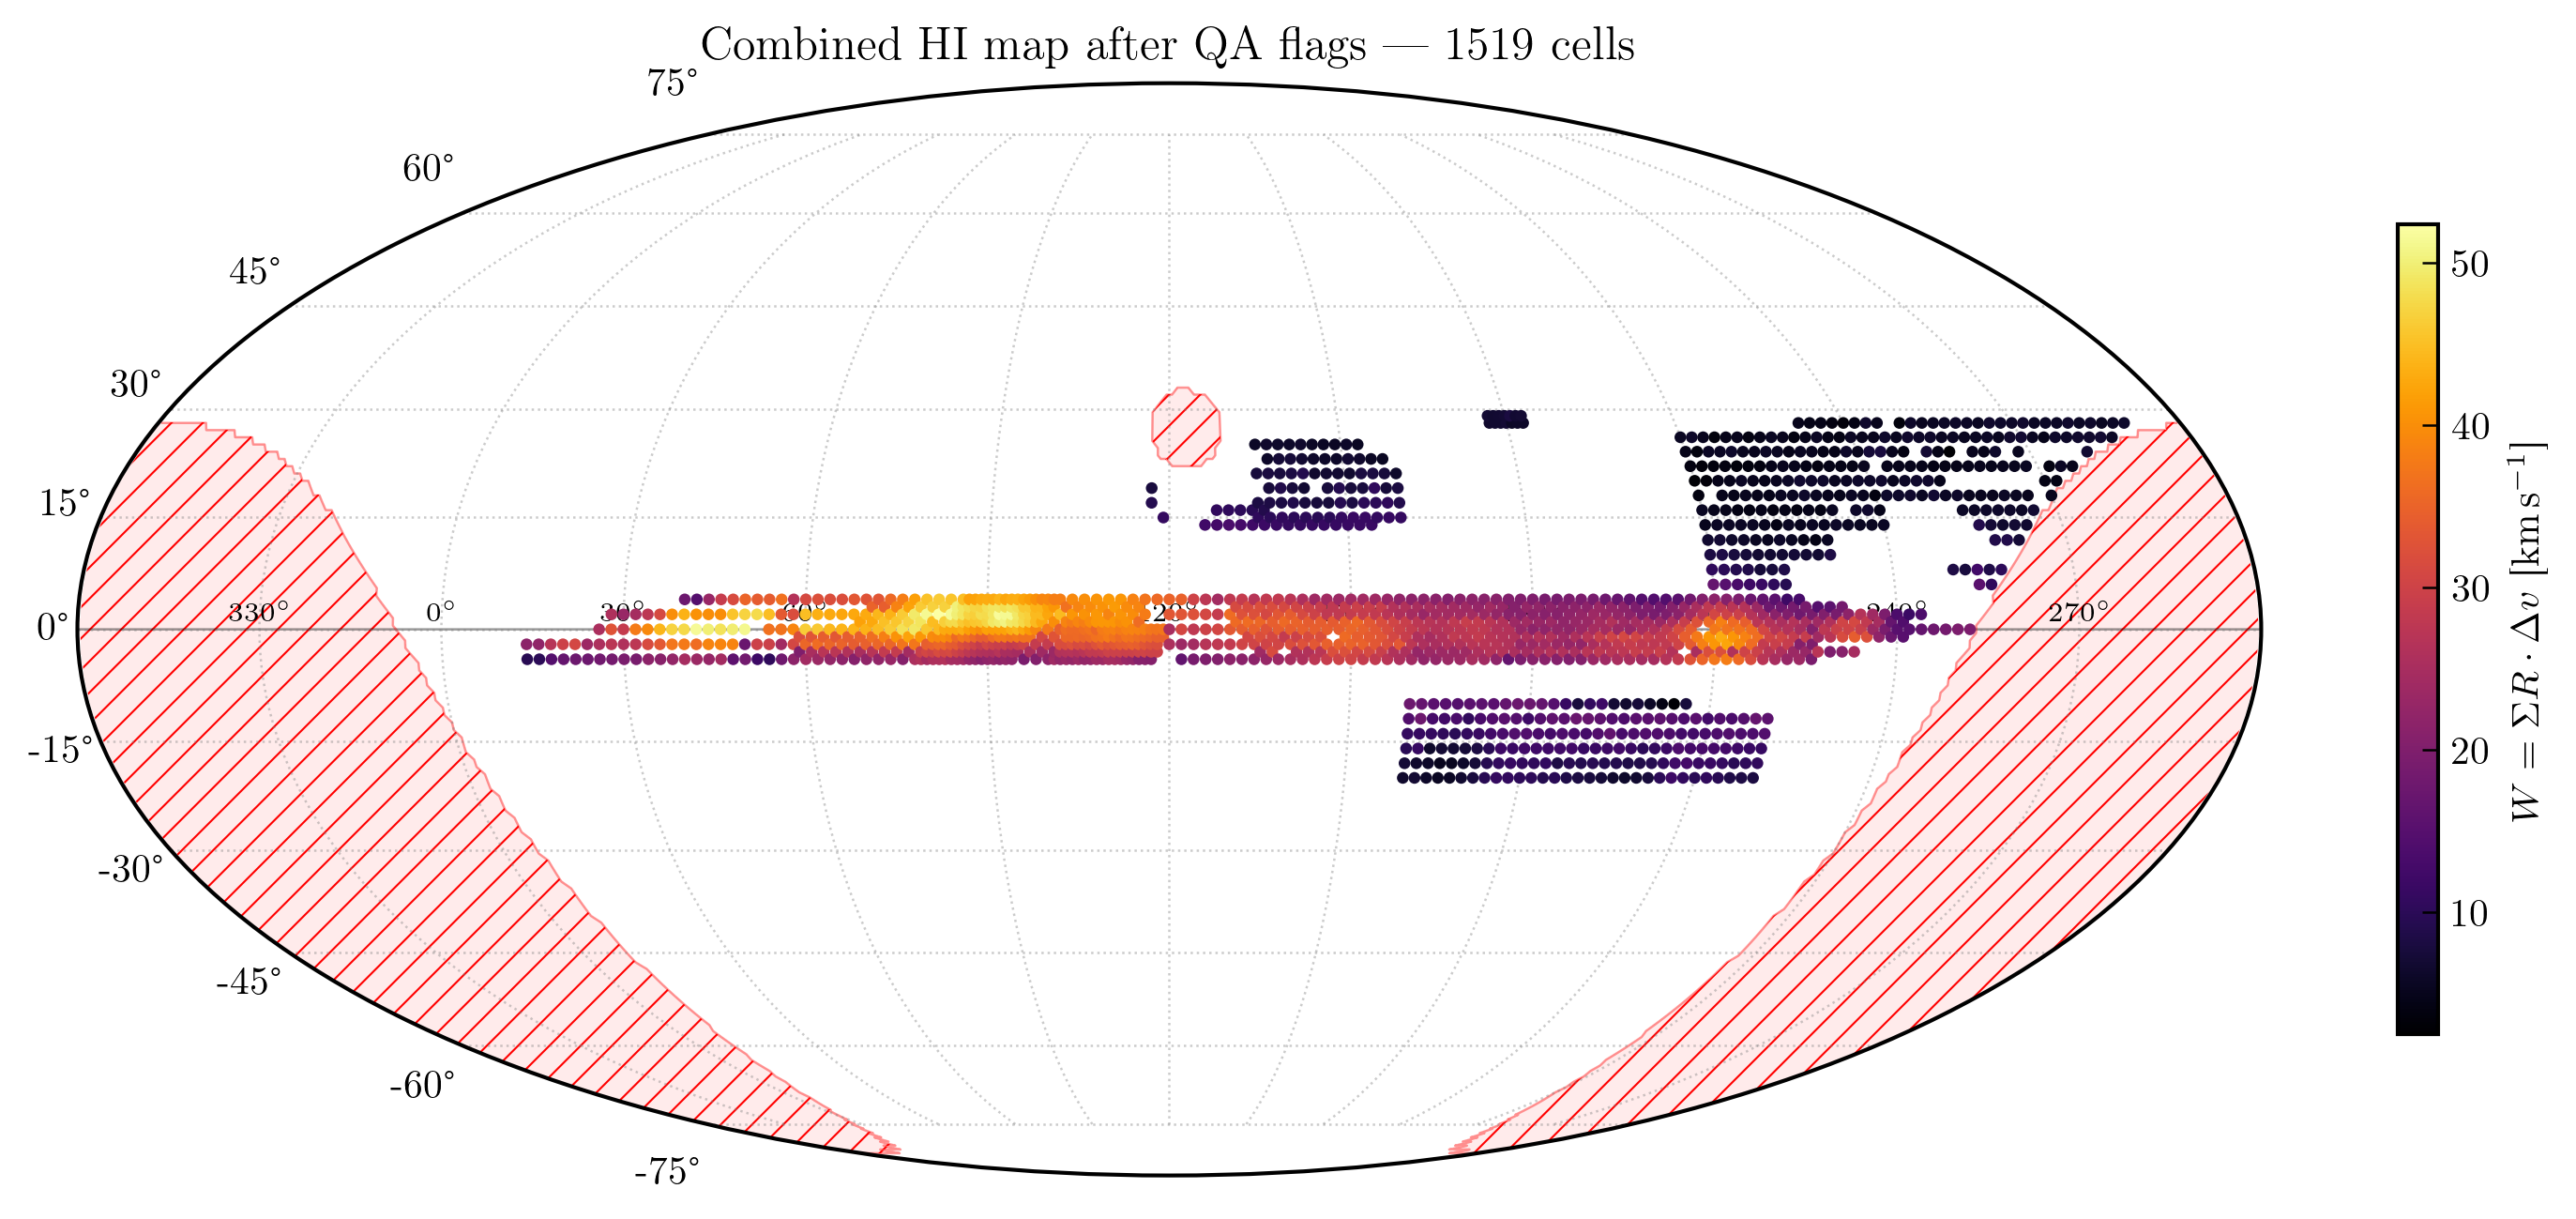

In [49]:
# Combined HI map after QA flags
flagged_pointings = {(c['gl'], c['gb']) for c in neighbor_cells
                     if c['W_flag'] or c['peak_v_flag']}
clean_results = {k: v for k, v in cell_results_combined.items() if k not in flagged_pointings}

gl_clean, gb_clean, W_clean = compute_cell_W(clean_results, dv_kms)
fig, ax = plot_survey_mollweide(
    gl_clean, gb_clean, W_clean,
    center_l=MOLL_CENTER_L,
    cbar_label=r"$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]",
    cmap="inferno",
    marker_size=SS_FINE,
    title=f'Combined HI map after QA flags --- {len(W_clean)} cells',
)
print(f'Removed {len(flagged_pointings)} flagged cells from the combined map')
plt.show()

## 7. Summary

In [50]:
all_times = [r['time'] for r in records]
t0 = dt.datetime.fromtimestamp(min(all_times), tz=dt.UTC)
t1 = dt.datetime.fromtimestamp(max(all_times), tz=dt.UTC)

# Recompute counts after outlier removal
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

# Summed integration time (science dumps only)
NBLOCKS = 1025
NSAMPLES = 32768
T_INT = NBLOCKS * NSAMPLES / SAMPLE_RATE_HZ  # 13.107 s per dump
total_int_s = n_sci * T_INT

print(f'Scan grid:  {len(gb_vals)} x {len(gl_vals)} = {len(cell_results_combined)} cells with combined data')
print(f'LO freqs:   {lo_unique} MHz')
print(f'Start:      {t0:%Y-%m-%d %H:%M:%S UTC}')
print(f'End:        {t1:%Y-%m-%d %H:%M:%S UTC}')
print(f'Integration: {total_int_s/3600:.1f} hr ({n_sci} science dumps x {T_INT:.1f} s)')
print(f'Dumps:      {N} ({n_cal} cal + {n_sci} science)')
print(f'Channels:   {NFFT} (dnu={df_khz:.2f} kHz)')

if 'neighbor_cells' in globals():
    print(f'Neighbor QA: {len(neighbor_cells)} cells analyzed')
    print(f'  W flags: {neighbor_w_flag_count}, peak_v flags: {neighbor_peak_flag_count}, any: {neighbor_any_flag_count}')

Scan grid:  34 x 228 = 1536 cells with combined data
LO freqs:   [1420.0, 1421.0] MHz
Start:      2026-04-16 09:59:51 UTC
End:        2026-04-23 22:15:06 UTC
Integration: 47.0 hr (12886 science dumps x 13.1 s)
Dumps:      12886 (0 cal + 12886 science)
Channels:   1024 (dnu=2.50 kHz)
Neighbor QA: 1536 cells analyzed
  W flags: 16, peak_v flags: 2, any: 17
